x* = (2.4186, 3.4130)   f* = 0.677333


data: [
  "contour with fields colorscale, contours, opacity, transpose, type, x, y, and z",
  "scatter with fields marker, mode, name, type, x, and y"
]

layout: "layout with fields height, margin, template, title, width, xaxis, and yaxis"

data: [
  "surface with fields colorscale, opacity, type, x, y, and z",
  "scatter3d with fields marker, mode, name, type, x, y, and z"
]

layout: "layout with fields height, margin, scene, template, title, and width"

data: [
  "scatter with fields line, mode, name, type, x, and y",
  "scatter with fields line, mode, name, type, x, and y"
]

layout: "layout with fields height, margin, template, title, width, xaxis, and yaxis"

data: [
  "contour with fields colorscale, contours, opacity, showscale, transpose, type, x, y, and z",
  "scatter with fields marker, mode, name, type, x, and y"
]

layout: "layout with fields height, margin, sliders, template, title, updatemenus, width, xaxis, and yaxis"


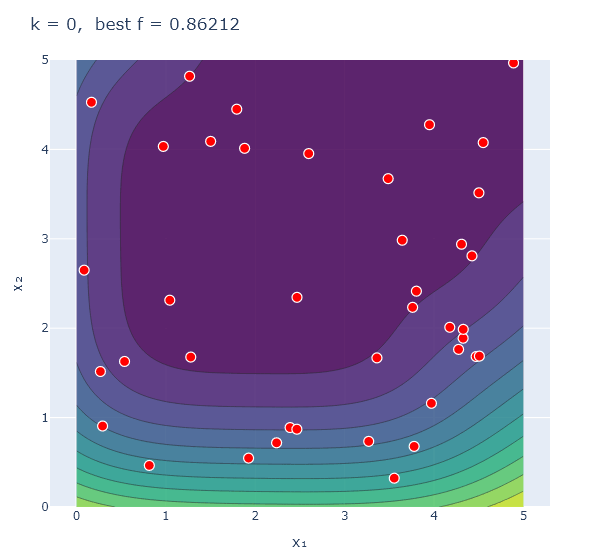


сохранено в c:\programming\optimization-methods\immune_system/:
  contour.html / .png
  surface3d.html / .png
  convergence.html / .png
  population.html  (интерактивная анимация)
  evolution.gif    (61 кадров)


In [4]:
using PlotlyJS, Random, Statistics, Printf, Base64
import PlotlyKaleido
import FileIO
using Images

PlotlyKaleido.start()

OUTDIR = joinpath(@__DIR__, "immune_system")
isdir(OUTDIR) || mkdir(OUTDIR)
FRAMES = joinpath(OUTDIR, "frames")
isdir(FRAMES) || mkdir(FRAMES)

# целевая функция f2, n=2, 10 "лисьих нор" с центрами (1+j, 2+j)
function f2(x::AbstractVector)
    s = 1/200
    @inbounds for j in 1:10
        a1, a2 = 1+j, 2+j
        s += 1 / (j + (x[1]-a1)^4 + (x[2]-a2)^4)
    end
    return 1/s
end

# Шаг 1: начальная популяция равномерно на D, f вычислена
function init_population(Np, α, β, rng)
    n = length(α)
    pop = [α .+ (β .- α) .* rand(rng, n) for _ in 1:Np]
    fit = [f2(x) for x in pop]
    return pop, fit
end

# Шаг 2: сортировка + пропорциональное клонирование (s лучших, j-я → ⌈ηNp/j⌉ клонов)
function clone_proportional(pop, fit, s, η, Np)
    order = sortperm(fit)
    parents = order[1:s]
    clones = Vector{Vector{Float64}}()
    owner  = Int[]
    for (rank, pidx) in enumerate(parents)
        nc = max(1, round(Int, η * Np / rank))
        for _ in 1:nc
            push!(clones, copy(pop[pidx])); push!(owner, pidx)
        end
    end
    return parents, clones, owner
end

# Шаг 3: мутация координат с амплитудой r*(β-α), repeat-on-reject для соблюдения D
function mutate!(clones, α, β, r, rng)
    n = length(α)
    for c in clones
        for i in 1:n
            if rand(rng) < 0.5
                while true
                    ξ = (2*rand(rng) - 1) * r * (β[i] - α[i])
                    v = c[i] + ξ
                    if α[i] ≤ v ≤ β[i]; c[i] = v; break; end
                end
            end
        end
    end
end

# Шаг 4: у каждого родителя — лучший клон-мутант; замена при улучшении
function selection!(pop, fit, parents, clones, owner)
    fclones = [f2(c) for c in clones]
    for pidx in parents
        mask = findall(==(pidx), owner)
        isempty(mask) && continue
        (fbest, kbest) = findmin(view(fclones, mask))
        if fbest < fit[pidx]
            pop[pidx] = clones[mask[kbest]]
            fit[pidx] = fbest
        end
    end
end

# Шаг 5: d худших клеток заменяем случайными на D
function refresh!(pop, fit, d, α, β, rng)
    order = sortperm(fit; rev=true)
    n = length(α)
    for idx in order[1:d]
        pop[idx] = α .+ (β .- α) .* rand(rng, n)
        fit[idx] = f2(pop[idx])
    end
end

# Шаги 6–7: основной цикл
function ais(; Np=40, s=10, d=5, K=60, η=0.6, r=0.3,
              α=[0.0,0.0], β=[5.0,5.0], seed=42)
    rng = MersenneTwister(seed)
    pop, fit = init_population(Np, α, β, rng)
    history_pop  = [deepcopy(pop)]
    history_best = [minimum(fit)]
    history_mean = [mean(fit)]
    for k in 1:K
        parents, clones, owner = clone_proportional(pop, fit, s, η, Np)
        mutate!(clones, α, β, r, rng)
        selection!(pop, fit, parents, clones, owner)
        refresh!(pop, fit, d, α, β, rng)
        push!(history_pop, deepcopy(pop))
        push!(history_best, minimum(fit))
        push!(history_mean, mean(fit))
    end
    kbest = argmin(fit)
    return (x_star=pop[kbest], f_star=fit[kbest],
            history_pop=history_pop, history_best=history_best, history_mean=history_mean)
end

result = ais(Np=40, s=10, d=5, K=60, η=0.6, r=0.3, seed=42)
@printf "x* = (%.4f, %.4f)   f* = %.6f\n" result.x_star[1] result.x_star[2] result.f_star

# сетка для контура / поверхности
xs = range(0, 5, length=120)
ys = range(0, 5, length=120)
Z  = [f2([x,y]) for y in ys, x in xs]

# контур + найденный минимум
p_contour = Plot(
    [contour(x=collect(xs), y=collect(ys), z=Z, colorscale="Viridis",
             contours=attr(showlabels=true), opacity=0.9),
     scatter(x=[result.x_star[1]], y=[result.x_star[2]], mode="markers",
             marker=attr(color="red", size=12, symbol="diamond"), name="x*")],
    Layout(title="f₂: контур + найденный минимум",
           xaxis=attr(title="x₁"), yaxis=attr(title="x₂", scaleanchor="x"),
           width=700, height=600))
savefig(p_contour, joinpath(OUTDIR, "contour.html"))
savefig(p_contour, joinpath(OUTDIR, "contour.png"), width=900, height=760)
display(p_contour)

# 3D-поверхность
p_surface = Plot(
    [surface(x=collect(xs), y=collect(ys), z=Z, colorscale="Viridis", opacity=0.95),
     scatter3d(x=[result.x_star[1]], y=[result.x_star[2]], z=[result.f_star],
               mode="markers", marker=attr(color="red", size=6, symbol="diamond"), name="x*")],
    Layout(title="f₂(x₁,x₂) на D=[0,5]²",
           scene=attr(xaxis_title="x₁", yaxis_title="x₂", zaxis_title="f"),
           width=750, height=620))
savefig(p_surface, joinpath(OUTDIR, "surface3d.html"))
savefig(p_surface, joinpath(OUTDIR, "surface3d.png"), width=950, height=780)
display(p_surface)

# сходимость
iters = 0:length(result.history_best)-1
p_conv = Plot([
    scatter(x=collect(iters), y=result.history_best, mode="lines+markers",
            name="best f", line=attr(color="crimson", width=2)),
    scatter(x=collect(iters), y=result.history_mean, mode="lines",
            name="mean f", line=attr(color="steelblue", width=2, dash="dash"))
], Layout(title="Сходимость ИИС (log-шкала)",
          xaxis=attr(title="итерация k"),
          yaxis=attr(title="f", type="log"),
          width=750, height=420))
savefig(p_conv, joinpath(OUTDIR, "convergence.html"))
savefig(p_conv, joinpath(OUTDIR, "convergence.png"), width=950, height=540)
display(p_conv)

# интерактивная анимация: slider + play/pause
frames = [
    frame(data=[attr(x=[p[1] for p in result.history_pop[k]],
                     y=[p[2] for p in result.history_pop[k]])],
          name=string(k-1),
          traces=[1])                        # индекс trace_p (0-based)
    for k in 1:length(result.history_pop)
]

trace_c = contour(x=collect(xs), y=collect(ys), z=Z, colorscale="Viridis",
                  contours=attr(showlabels=true), opacity=0.85, showscale=true)
trace_p = scatter(x=[p[1] for p in result.history_pop[1]],
                  y=[p[2] for p in result.history_pop[1]],
                  mode="markers",
                  marker=attr(color="red", size=8, line=attr(color="white", width=1)),
                  name="популяция")

steps = [attr(method="animate", label=string(k-1),
              args=[[string(k-1)], attr(mode="immediate",
                    frame=attr(duration=0, redraw=true), transition=attr(duration=0))])
         for k in 1:length(result.history_pop)]

layout_anim = Layout(title="Популяция на итерации (интерактивно)",
    xaxis=attr(title="x₁", range=[0,5]),
    yaxis=attr(title="x₂", range=[0,5], scaleanchor="x"),
    width=750, height=700,
    sliders=[attr(active=0, currentvalue=attr(prefix="k = "), steps=steps, pad=attr(t=50))],
    updatemenus=[attr(type="buttons", showactive=false,
        buttons=[
            attr(label="▶ play", method="animate",
                 args=[nothing, attr(fromcurrent=true,
                       frame=attr(duration=200, redraw=true), transition=attr(duration=0))]),
            attr(label="❚❚ pause", method="animate",
                 args=[[nothing], attr(mode="immediate",
                       frame=attr(duration=0, redraw=false), transition=attr(duration=0))])
        ])])

p_anim = Plot([trace_c, trace_p], layout_anim, frames)
savefig(p_anim, joinpath(OUTDIR, "population.html"))
display(p_anim)

# GIF: рендерим кадры и склеиваем
frame_files = String[]
for (k, pop_k) in enumerate(result.history_pop)
    pk = Plot([
        contour(x=collect(xs), y=collect(ys), z=Z, colorscale="Viridis",
                contours=attr(showlabels=false), opacity=0.85, showscale=false),
        scatter(x=[p[1] for p in pop_k], y=[p[2] for p in pop_k], mode="markers",
                marker=attr(color="red", size=10, line=attr(color="white", width=1.2)),
                name="pop")
    ], Layout(title="k = $(k-1),  best f = $(round(result.history_best[k], digits=5))",
              xaxis=attr(title="x₁", range=[0,5]),
              yaxis=attr(title="x₂", range=[0,5], scaleanchor="x"),
              width=600, height=560, showlegend=false))
    fp = joinpath(FRAMES, @sprintf("frame_%03d.png", k-1))
    savefig(pk, fp, width=600, height=560)
    push!(frame_files, fp)
end

imgs = [FileIO.load(f) for f in frame_files]
stack = cat(imgs...; dims=3)
gif_path = joinpath(OUTDIR, "evolution.gif")
FileIO.save(gif_path, stack; fps=8)

# inline-показ GIF в выводе ячейки
b64 = base64encode(read(gif_path))
display("text/html", "<img src=\"data:image/gif;base64,$b64\" style=\"max-width:600px;\"/>")

println("\nсохранено в $OUTDIR/:")
println("  contour.html / .png")
println("  surface3d.html / .png")
println("  convergence.html / .png")
println("  population.html  (интерактивная анимация)")
println("  evolution.gif    ($(length(frame_files)) кадров)")